# 第65篇 | 链式法则与计算图：反向传播的数学基础

> **摘要**：链式法则是深度学习「反向传播」算法的全部数学基础。本篇从单变量链式法则出发，推广到多变量链式法则，引入计算图（Computational Graph）的直观表示，并用代码从零实现一个简单的反向传播引擎。理解本篇后，你将彻底明白所有深度学习框架（PyTorch、TensorFlow）的自动微分是如何工作的。

嗨，我是小荷～ 如果问你「深度学习最核心的数学是什么」，我会毫不犹豫地说是**链式法则**。之前我说过，最先该学的概念是导数。如果说微积分里的导数是研究“多米诺骨牌的第一块倒下后，最后一块会怎么动”，那么单变量链式法则（Single-Variable Chain Rule）就是用来计算这套骨牌在“连环传导”时的物理放大系数。它是深度学习中反向传播算法（Backpropagation）的核心数学基石，没有它，我们就无法训练深层神经网络——因为损失函数对第50层参数的导数，需要连续应用50次链式法则才能算出来。今天我们把这个「深度学习引擎」的数学原理彻底拆开来看。

---

## 一、单变量链式法则：从直观到严格

**例子：代工厂的“连环涨价**

想象一个由三家工厂串联起来的经济链条：
- 原材料价格 x 决定了 芯片的成本y）。
- 芯片的成本y 进而决定了 智能手机的售价z。

这时候，它们之间有两段独立的变动关系（也就是两个普通的“单变量导数”）：
- 第一段传导 dy/dx = 4：原材料每涨 1 块钱，芯片成本就会跟着涨 3 块钱。
- 第二段传导 dz/dy = 5：芯片成本每涨 1 块钱，手机售价就会狠狠地涨 5 块钱。

现在，苹果公司的 CEO 走过来，想知道一个跨越维度的底层秘密：“如果最底层的原材料 x 涨了 1 块钱，最终手机的售价（z会涨多少钱？”

你根本不需要重新推导复杂的公式，用常识就能算出来：原材料涨 1元 --> 芯片涨 3 元 --> 手机涨 3 * 5 = 15 元。这个把两段传导倍数“乘起来”的常识，在微积分里就叫链式法则。

链式法则让我们能够计算「**复合函数**」的导数。比如 f(g(h(x)))，如果对 x 求导，就需要一层一层「链」下去。

**严格数学定义**

**定理（单变量链式法则）**：
设 y = f(u)，u = g(x)，且 f 在 u 处可导，g 在 x 处可导，则复合函数 y = f(g(x)) 在 x 处可导，且：

$$\frac{dy}{dx} = \frac{df}{du} \cdot \frac{dg}{dx} = f'(g(x)) \cdot g'(x)$$

**直觉理解**：
- df/du：外层函数 f 对中间变量 u 的变化率
- dg/dx：内层函数 g 对输入 x 的变化率
- 两者相乘：x 的变化通过 g 影响 u，再通过 f 影响 y

**代码演示**

下面我们用数值差分验证单变量链式求导法则的正确性，区分两种求导方式：
- 数值导数`numerical_derivative`：f'(x) = (f(x+h)-f(x))/h ，仅依靠函数输入输出，不需要手动推导公式，计算机自动近似；
- 解析导数`composite_derivative_analytic`：f'(x) = np.cos(x**2) * 2 * x，使用链式法则数学推导得到精确表达式，无近似误差。

In [3]:
# 链式法则的数值验证
import numpy as np

def numerical_derivative(f, x, h=1e-7):
    """
    用定义式数值计算导数
    参数:
        f: 要求导的函数
        x: 求导位置
        h: 增量（不能太大也不能太小）
    返回:
        f'(x) 的数值近似
    """
    return (f(x + h) - f(x)) / h

# 测试复合函数：y = f(g(x)) = sin(x²)
def g(x):
    """内层函数 g(x) = x²"""
    return x ** 2

def f(u):
    """外层函数 f(u) = sin(u)"""
    return np.sin(u)

def composite(x):
    """复合函数 f(g(x)) = sin(x²)"""
    return f(g(x))

def composite_derivative_analytic(x):
    """
    解析导数（用链式法则手动推导）
    d/dx [sin(x²)] = cos(x²) · 2x
    """
    return np.cos(x**2) * 2 * x

# 在多个点验证
test_points = [0, 0.5, 1.0, 1.5, 2.0]

print("=== 单变量链式法则验证 ===")
print(f"{'x':<10} {'数值导数':<20} {'解析导数':<20} {'误差':<15}")
print("-" * 65)

for x0 in test_points:
    num_deriv = numerical_derivative(composite, x0)
    ana_deriv = composite_derivative_analytic(x0)
    error = abs(num_deriv - ana_deriv)
    print(f"{x0:<10.4f} {num_deriv:<20.10f} {ana_deriv:<20.10f} {error:<15.2e}")

=== 单变量链式法则验证 ===
x          数值导数                 解析导数                 误差             
-----------------------------------------------------------------
0.0000     0.0000001000         0.0000000000         1.00e-07       
0.5000     0.9689125055         0.9689124217         8.38e-08       
1.0000     1.0806044981         1.0806046117         1.14e-07       
1.5000     -1.8845212812        -1.8845208682        4.13e-07       
2.0000     -2.6145739385        -2.6145744835        5.45e-07       


代码遍历了 5 个不同 x 点，数值导数和链式法则算出的解析导数几乎完全重合，所有测试点的绝对误差均维持在 10^(-7) - 10^(-8) 量级，误差极小，直接证明链式法则数学成立，链式法则让我们能够分解复杂复合函数的求导过程。

---

## 二、多变量链式法则：反向传播的起点


如果说单变量链式法则是一条线性的“单线代工厂”（x -> y -> z），那么多变量链式法则（Multi-Variable Chain Rule）就是一张错综复杂的“条条大路通罗马的分流网络”。在机器学习中，一个参数往往会通过好几条不同的路径同时影响最终的损失函数（Loss）。多变量链式法则就是用来计算这种“多路并发、全网汇聚”的总账系数。

**例子：**

想象一下，有一家科技公司：创始人的勤奋程度 x，同时决定了两个部门的产出：
- 研发部的产品质量u 和 市场部的宣传力度v。
- 而 产品质量u 和 宣传力度v，共同决定了公司最终的 总利润z。

这时候，创始人想知道一个底层秘密：“如果我多付出 1 分的勤奋 x，公司的总利润 z 最终会变动多少？”

我们来看创始人的勤奋是如何顺着网络“分流”并“汇聚”的：
- 研发部路径：勤奋提升了产品质量x -> u，高质量又换来了高利润u -> z。
- 市场部路径：勤奋同时也提升了宣传力度x -> v，强宣传也换来了高利润v -> z。

  创始人付出的每一分勤奋，都会同时在这两条路上奔跑。所以，最终总利润的变化，等于两条路径各自传导效应的“相加”。


**多变量链式法则（严格表述）**

**定理**：设 y = f(u₁, u₂, ..., uₘ)，其中每个 uᵢ = gᵢ(x₁, x₂, ..., xₙ)，则：

$$\frac{\partial y}{\partial x_j} = \sum_{i=1}^{m} \frac{\partial y}{\partial u_i} \cdot \frac{\partial u_i}{\partial x_j}$$

**直觉理解**：
- ∂y/∂uᵢ：损失 y 对中间变量 uᵢ 的偏导（「上游梯度」）
- ∂uᵢ/∂xⱼ：中间变量 uᵢ 对输入 xⱼ 的偏导（「本地梯度」）
- 求和：因为 y 依赖于所有 uᵢ，每个 uᵢ 又依赖于 xⱼ，所以要加起来（**加法法则**）

**代码演示**

下面的代码继续用数值逼近和解析推导，验证微积分中的多变量链式法则（Multivariable Chain Rule）。

1.  数学模型：多重复合函数分层结构。函数嵌套链路：
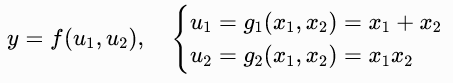
展开完整复合函数：y = (x₁ + x₂)² + (x₁x₂)²
2. 数值验证。`numerical_partial_derivative` 通过极小步长 h = 10^(-7) 的有限差分法计算数值导数。
3. 多变量链式法则的解析推导。`analytic_partial_x1` 和 `analytic_partial_x2` 展示了链式法则的精髓——“路径求和”：
   - 当输入 x₁ 发生变化时，它会同时影响中间变量 u₁, u₂
   - 根据链式法则,  x₁ 对最终结果 y 的总影响，等于它通过 u₁ 传导的影响 (∂y/∂u₁)▪(∂u₁/∂x₁) 加上它通过u₂ 传导的影响 (∂y/∂u₂)▪(∂u₂/∂x₁)

In [4]:
# 多变量链式法则的数值验证
import numpy as np

def numerical_partial_derivative(f, x, idx, h=1e-7):
    """
    用定义式数值计算偏导数
    参数:
        f: 多元函数 f(x1, x2, ..., xn)
        x: 输入向量
        idx: 要对哪个变量求偏导
        h: 增量
    返回:
        ∂f/∂x_idx 的数值近似
    """
    x_plus_h = x.copy()
    x_plus_h[idx] += h
    return (f(x_plus_h) - f(x)) / h

# 测试多变量复合函数：
# y = f(u1, u2) = u1² + u2²
# 其中 u1 = g1(x1, x2) = x1 + x2
#       u2 = g2(x1, x2) = x1 * x2

def g1(x1, x2):
    """内层函数1：u1 = x1 + x2"""
    return x1 + x2

def g2(x1, x2):
    """内层函数2：u2 = x1 * x2"""
    return x1 * x2

def f(u1, u2):
    """外层函数：y = u1² + u2²"""
    return u1**2 + u2**2

def composite_multi(x1, x2):
    """复合函数：y = (x1+x2)² + (x1*x2)²"""
    return f(g1(x1, x2), g2(x1, x2))

def analytic_partial_x1(x1, x2):
    """
    解析偏导数 ∂y/∂x1（用多变量链式法则）
    ∂y/∂x1 = (∂y/∂u1)*(∂u1/∂x1) + (∂y/∂u2)*(∂u2/∂x1)
             = (2*u1) * 1 + (2*u2) * x2
             = 2*(x1+x2) + 2*(x1*x2) * x2
    """
    u1 = g1(x1, x2)
    u2 = g2(x1, x2)
    dy_du1 = 2 * u1
    dy_du2 = 2 * u2
    du1_dx1 = 1.0
    du2_dx1 = x2
    return dy_du1 * du1_dx1 + dy_du2 * du2_dx1

def analytic_partial_x2(x1, x2):
    """
    解析偏导数 ∂y/∂x2（用多变量链式法则）
    ∂y/∂x2 = (∂y/∂u1)*(∂u1/∂x2) + (∂y/∂u2)*(∂u2/∂x2)
             = (2*u1) * 1 + (2*u2) * x1
    """
    u1 = g1(x1, x2)
    u2 = g2(x1, x2)
    dy_du1 = 2 * u1
    dy_du2 = 2 * u2
    du1_dx2 = 1.0
    du2_dx2 = x1
    return dy_du1 * du1_dx2 + dy_du2 * du2_dx2

# 验证
x1_test, x2_test = 2.0, 3.0
x = np.array([x1_test, x2_test])

print("=== 多变量链式法则验证 ===")
print(f"测试点: (x1, x2) = ({x1_test}, {x2_test})")
print(f"\n∂y/∂x1:")
print(f"  数值导数: {numerical_partial_derivative(lambda x: composite_multi(x[0], x[1]), x, 0):.6f}")
print(f"  解析导数: {analytic_partial_x1(x1_test, x2_test):.6f}")
print(f"  误差: {abs(numerical_partial_derivative(lambda x: composite_multi(x[0], x[1]), x, 0) - analytic_partial_x1(x1_test, x2_test)):.2e}")

print(f"\n∂y/∂x2:")
print(f"  数值导数: {numerical_partial_derivative(lambda x: composite_multi(x[0], x[1]), x, 1):.6f}")
print(f"  解析导数: {analytic_partial_x2(x1_test, x2_test):.6f}")
print(f"  误差: {abs(numerical_partial_derivative(lambda x: composite_multi(x[0], x[1]), x, 1) - analytic_partial_x2(x1_test, x2_test)):.2e}")

=== 多变量链式法则验证 ===
测试点: (x1, x2) = (2.0, 3.0)

∂y/∂x1:
  数值导数: 46.000001
  解析导数: 46.000000
  误差: 9.64e-07

∂y/∂x2:
  数值导数: 34.000000
  解析导数: 34.000000
  误差: 3.97e-07


验证结果显示，无论是 ∂y/∂x1 还是 ∂y/∂x2 ，解析推导的结果与数值逼近的结果精确吻合，误差在 10 ^ (-7) 级别。这在工程上被称为“梯度检查（Gradient Check）”，是开发自定义神经网络层时必不可少的排错手段。

---

## 三、计算图：把链式法则画出来

### 什么是计算图？

**计算图（Computational Graph）** 是把计算过程用「节点」和「边」表示出来的图结构：
- **节点**：表示变量（输入、中间变量、输出）
- **边**：表示操作（加、乘、函数变换等）


例如对简单的数学复合公式：z = (x + y) * y 为了让计算机能够理解和计算它，计算图会引入中间变量（比如u），把它拆解为两步：
- u = x + y
- z = u * y

计算图：

In [ ]:
x ---→ [+] ---→ u ---→ [*] ---→ z
        |               |
y ------------------------------(y 分流同时喂给加法和乘法)

在这张图里：
- 叶子节点（输入）：x 和 y（你输入的数据或模型的权重）。
- 内部节点（算子）：+ 和 *（执行的数学运算）。
- 输出节点：z（最终的 Loss 损失值）。

### 前向传播 vs 反向传播

**前向传播（Forward Pass）**：
- 从输入开始，沿着计算图「从左到右」计算
- 目的：得到最终输出值 f(x,y)

例如对上面的 z = (x + y) * y ，令 x=1, y=2，信号沿着箭头向右流动：
- 经过 + 节点：u = 1 + 2 = 3
- 经过 times 节点：z = 3 times 2 = 6最终，流水线吐出了计算结果 z=6。

**反向传播（Backward Pass）**：这是计算图最恐怖的能力。如果最终的损失值 $z$ 太高了，模型想要优化，就需要知道：“最前端的输入 $x$ 和 $y$，各自应该承担多少罪责（梯度）？”
- 从输出开始，沿着计算图「从右到左」计算梯度
- 目的：得到损失对所有参数的梯度 ∇f

还是用x=1, y=2，顺着箭头逆流而退（从右往左）
- 最外层：自己对自己的导数 ∂z/∂z =1。
- 退一步（乘法节点）：根据乘法求导法则，∂z/∂u = y = 2；同时另一路 ∂z/∂y_右路 = u = 3。
- 再退一步（加法节点）：加法对各分量的导数都是 1。根据链式法则（连乘）：
   - ∂z/∂x = (∂z/∂u) * (∂u/∂x) = 2 * 1 = 2
   - ∂z/∂y_左路 = (∂z/∂u) * (∂u/∂y) = 2 * 1 = 2
- 全网汇聚（多变量链式法则）：因为 y既走左路又走右路，把两路贡献相加：∂z/∂y = ∂z/∂y_左路 + ∂z/∂y_右路 = 2 + 3 = 5。

**代码演示**

下面我们手写一个极简的 ComputationalGraph 类，复现深度学习 ** 自动微分（Autograd）** 核心逻辑，测试函数：f(x,y)=(x+y)^2：
1. 前向传播：顺着计算流从输入到输出，存储每一步运算的数值。正向：x,y --> z = x + y --> f = z²
2. 反向传播：从输出节点倒推，逐层使用链式法则累加传递梯度，得到输入变量的偏导数。
   反向传播链式推导过程
   - 起点初始化：(∂f/∂f)=1
   - 第一层链式：(∂f/∂z) = (∂f/∂f) · (df/dz) = 1 · 2z)
   - 第二层链式：
       - (∂f/∂x) = (∂f/∂z) · (∂z/∂x) = 2z · 1
       - (∂f/∂y) = (∂f/∂z) · (∂z/∂y) = 2z · 1
3. 核心机制
   - 节点存储：每个节点同时缓存value（前向数值）和grad（反向梯度），是框架自动微分的基础；
   - 梯度传递规则：上游梯度 × 当前运算的导数 = 当前节点总梯度，本质是链式法则；
   - 输出梯度初始化为 1：反向传播必须从输出端开启梯度流。

In [9]:
import numpy as np

class ComputationalGraph:
    """
    简易计算图类，模拟深度学习框架自动微分底层逻辑
    实现两层核心流程：前向传播计算输出、反向传播链式求梯度
    示例函数：f(x,y) = (x+y)²
    """
    def __init__(self):
        # 字典存储所有计算节点，key=节点名称，value={'value':节点数值, 'grad':节点梯度}
        self.nodes = {}
        # 预留边容器，本示例简化未使用，用于复杂多分支计算图记录运算依赖关系
        self.edges = []

    def forward(self, x, y):
        """
        前向传播：顺着计算图从输入到输出逐层计算数值
        参数：
            x: 输入变量1
            y: 输入变量2
        返回：
            最终输出f=(x+y)²的计算结果
        """
        # 节点x：存储输入值，梯度初始化为0
        self.nodes['x'] = {'value': x, 'grad': 0.0}
        # 节点y：存储输入值，梯度初始化为0
        self.nodes['y'] = {'value': y, 'grad': 0.0}

        # 中间节点z：执行加法运算 z = x + y
        z_value = x + y
        self.nodes['z'] = {'value': z_value, 'grad': 0.0}

        # 输出节点f：执行平方运算 f = z²
        f_value = z_value ** 2
        self.nodes['f'] = {'value': f_value, 'grad': 0.0}

        # 返回最终输出结果
        return f_value

    def backward(self):
        """
        反向传播：从输出节点倒推，逐层用链式法则求所有节点梯度
        传播顺序：f → z → x、y
        返回：
            输入x的梯度 ∂f/∂x，输入y的梯度 ∂f/∂y
        """
        # 梯度初始化规则：输出节点对自身的偏导 ∂f/∂f = 1，作为反向传播起点
        self.nodes['f']['grad'] = 1.0

        # === 步骤1：链式求导，计算输出对中间变量z的梯度 ∂f/∂z ===
        # 运算关系 f = z²，单变量导数 df/dz = 2z
        z_value = self.nodes['z']['value']
        df_dz = 2 * z_value
        # 链式法则：上游梯度 × 当前运算导数，得到z节点总梯度
        self.nodes['z']['grad'] = df_dz * self.nodes['f']['grad']

        # === 步骤2：链式求导，分别计算输出对x、y的梯度 ∂f/∂x、∂f/∂y ===
        # 运算关系 z = x + y，偏导数 ∂z/∂x = 1，∂z/∂y = 1
        dz_dx = 1.0
        dz_dy = 1.0
        # 链式法则：∂f/∂x = ∂f/∂z * ∂z/∂x
        self.nodes['x']['grad'] = self.nodes['z']['grad'] * dz_dx
        # 链式法则：∂f/∂y = ∂f/∂z * ∂z/∂y
        self.nodes['y']['grad'] = self.nodes['z']['grad'] * dz_dy

        # 返回两个输入变量的梯度
        return self.nodes['x']['grad'], self.nodes['y']['grad']

# ---------------------- 测试代码执行流程 ----------------------
# 实例化计算图对象
graph = ComputationalGraph()
# 给定测试输入值
x_test, y_test = 2.0, 3.0

print("=== 计算图与反向传播 ===")
print(f"输入: x = {x_test}, y = {y_test}")

# 执行前向传播，逐层计算节点数值
f_value = graph.forward(x_test, y_test)
print(f"\n前向传播:")
print(f"  z = x + y = {graph.nodes['z']['value']}")
print(f"  f = z² = {f_value}")

# 执行反向传播，链式法则逐层求梯度
df_dx, df_dy = graph.backward()
print(f"\n反向传播（链式法则）:")
print(f"  ∂f/∂x = {df_dx:.6f}")
print(f"  ∂f/∂y = {df_dy:.6f}")

# 手动解析求导，验证反向传播梯度结果正确性
# 完整展开 f(x,y)=(x+y)²，直接求偏导 ∂f/∂x=2(x+y)、∂f/∂y=2(x+y)
analytic_df_dx = 2 * (x_test + y_test)
analytic_df_dy = 2 * (x_test + y_test)
print(f"\n解析验证:")
print(f"  ∂f/∂x (解析) = {analytic_df_dx:.6f}，误差 = {abs(df_dx - analytic_df_dx):.2e} ✓")
print(f"  ∂f/∂y (解析) = {analytic_df_dy:.6f}，误差 = {abs(df_dy - analytic_df_dy):.2e} ✓")

=== 计算图与反向传播 ===
输入: x = 2.0, y = 3.0

前向传播:
  z = x + y = 5.0
  f = z² = 25.0

反向传播（链式法则）:
  ∂f/∂x = 10.000000
  ∂f/∂y = 10.000000

解析验证:
  ∂f/∂x (解析) = 10.000000，误差 = 0.00e+00 ✓
  ∂f/∂y (解析) = 10.000000，误差 = 0.00e+00 ✓


测试点 x=2,y=3，z=5，理论梯度 ∂f/∂x=∂f/∂y=10；反向传播计算值与解析推导值完全一致，误差为 0，验证反向传播逻辑正确。

---

## 四、链式法则在深度学习中的应用

### 神经网络的训练流程

一个典型的神经网络训练步骤：

1. **前向传播**：输入 x → 经过多层线性变换和激活函数 → 输出 y_pred
2. **计算损失**：L = Loss(y_pred, y_true)
3. **反向传播**：用链式法则计算 ∂L/∂w₁, ∂L/∂w₂, ...
4. **参数更新**：wᵢ := wᵢ - η · ∂L/∂wᵢ（梯度下降）

### 为什么叫「反向」传播？

因为链式法则的应用顺序是「**从输出层往输入层方向**」传播的：
- 先算输出层参数的梯度
- 再算倒数第二层参数的梯度
- ...
- 最后算第一层参数的梯度

这就是为什么它叫「反向」传播（Backpropagation）。

**代码演示**

下面的代码把前面探讨的所有微积分概念（偏导数、梯度、链式法则）融合起来，基于 NumPy 从零手写一个神经网络训练全流程。
1. 前向传播：计算预测值，缓存所有中间激活 / 预激活变量，供反向传播复用。
     - 正向计算链路（前向传播）:(X -> z₁=XW₁+b₁ -> a₁=∂(z₁) -> z₂=a₁W₂+b₂ -> a₂=∂(z₂)=^y)
     - 线性变换与非线性激活：每一层的计算都遵循 z = X @ W + b（线性组合）和 a = sigmoid(z)（引入非线性）的模式。
     - 缓存机制（Cache）：在前向传播过程中，代码将中间变量（z1, a1, z2）保存在类的属性中。这是工程上的关键一步，因为这些中间值在后续的反向传播中计算局部导数时将被直接复用。
2. 反向传播：纯依靠多变量链式法则，一次性求解全部权重、偏置的梯度。backward 方法是整段代码的灵魂，它严格按照多变量链式法则，从输出层向输入层逐层反向推导梯度。
    - 反向梯度链路（多层多变量链式法则）: (L -> a₂ -> z₂ -> W₂,b₂ -> a₁ -> z₁ -> W₁,b₁)，每一步梯度传递都严格遵循多元链式求导：上游梯度 × 当前运算导数。
    - 输出层梯度：首先计算损失函数对预测值的导数，然后乘以 Sigmoid 激活函数的导数（sigmoid_derivative），得到损失对输出层加权输入的梯度 dl_dz2。
   - 权重与偏置梯度：利用矩阵乘法（如 a1.T @ dl_dz2），高效地计算出输出层权重 W2 和偏置 b2 的梯度。
   - 误差反向传递：通过 dl_dz2 @ self.W2.T，将误差信号从输出层“传递”回隐藏层，再乘以隐藏层的激活函数导数，最终求得隐藏层权重 W1 和偏置 b1 的梯度。
3. 参数更新与模型收敛：梯度下降迭代，沿负梯度方向修正权重，持续降低损失。
  - update_params 方法利用反向传播计算出的梯度字典，按照 w = w - η * grad 的规则更新网络中的所有参数。
4. 训练：在 n_epochs（100）次 的循环中，模型不断重复“前向传播预测 → 计算损失 → 反向传播求导 → 更新参数”的闭环。可视化图表清晰地展示了随着链式法则的驱动，MSE 损失值稳步下降，模型成功学习到了数据背后的规律。
5. 可视化曲线直观展示梯度下降的收敛过程

=== 神经网络训练（链式法则的实际应用）===
数据：100 个样本，2 个特征
训练轮数：100，学习率：0.1

  Epoch  20 | 损失: 0.249036
  Epoch  40 | 损失: 0.247403
  Epoch  60 | 损失: 0.246674
  Epoch  80 | 损失: 0.246306
  Epoch 100 | 损失: 0.246076


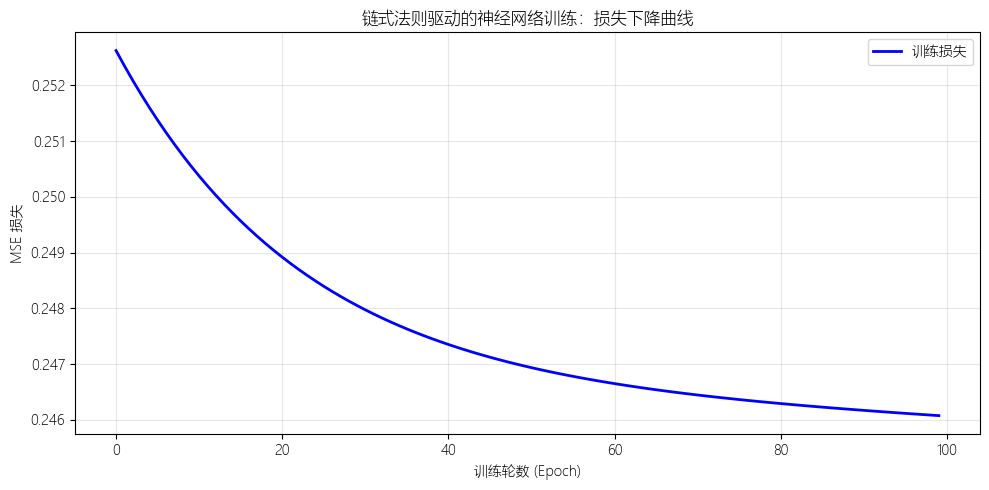

In [11]:
import numpy as np

# ====================== 绘图全局字体配置（解决中文、数学∇符号缺失报错） ======================
# 中文字体回退列表，依次加载微软雅黑、黑体、数学专用字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans'] 
# 修复坐标轴负号显示方框乱码
plt.rcParams['axes.unicode_minus'] = False
# 独立数学符号渲染字体，内置导数、梯度、积分等全部公式符号，不受中文字体限制
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# 设置全局随机种子42，每次运行权重、数据完全一致，实验可复现
np.random.seed(42)

# ====================== 两层全连接神经网络类定义 ======================
class SimpleNeuralNet:
    """
    2层全连接神经网络结构：
    输入层(2个特征) → 隐藏层(3个神经元+Sigmoid激活) → 输出层(1个神经元+Sigmoid激活)
    完整流程：前向传播计算预测值 → 反向传播链式求梯度 → 梯度下降更新权重
    """
    def __init__(self):
        # 初始化第一层权重 W1：输入2维 → 隐藏3维，形状(2,3)，小随机值避免饱和
        self.W1 = np.random.randn(2, 3) * 0.1
        # 隐藏层偏置 b1，一行三列，初始全0
        self.b1 = np.zeros((1, 3))
        # 第二层权重 W2：隐藏3维 → 输出1维，形状(3,1)
        self.W2 = np.random.randn(3, 1) * 0.1
        # 输出层偏置 b2，初始0
        self.b2 = np.zeros((1, 1))
        
    def sigmoid(self, z):
        """Sigmoid激活函数 σ(z) = 1/(1+e^(-z))，压缩输出到(0,1)，二分类输出"""
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, z):
        """Sigmoid导数（链式法则核心工具）：σ'(z) = σ(z) * (1 - σ(z))"""
        s = self.sigmoid(z)
        return s * (1 - s)
    
    def forward(self, X):
        """
        前向传播：顺着计算图从输入到输出逐层运算，缓存中间结果用于反向传播
        参数:
            X: 输入数据集，维度(n_samples, 2) n=样本数量，2个特征
        返回:
            a2: 模型预测概率 (n_samples,1)
        """
        # 第一层线性变换：X @ W1 + b1 矩阵乘法，得到隐藏层预激活z1
        self.z1 = X @ self.W1 + self.b1
        # 隐藏层Sigmoid激活，得到a1，缓存为实例变量，反向传播直接读取
        self.a1 = self.sigmoid(self.z1)
        
        # 第二层线性变换：隐藏层输出a1乘权重W2加偏置b2
        self.z2 = self.a1 @ self.W2 + self.b2
        # 输出层Sigmoid激活，最终预测值
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def backward(self, X, y_true, y_pred):
        """
        反向传播核心：多层多变量链式法则，从损失倒推所有权重、偏置的梯度
        参数:
            X: 原始输入特征
            y_true: 真实标签0/1
            y_pred: 前向传播得到的预测值a2
        返回:
            grads: 字典，存储全部参数梯度 dL/dW1, dL/db1, dL/dW2, dL/db2
        """
        n_samples = X.shape[0]
        
        # ====================== 输出层梯度计算（第一层链式） ======================
        # 损失为MSE：L = (1/n)Σ(y_pred - y_true)²
        # 损失对输出激活a2的偏导 ∂L/∂a2 = 2/n * (a2 - y_true)
        dl_da2 = (2 / n_samples) * (y_pred - y_true)
        
        # 激活层导数 ∂a2/∂z2 = σ'(z2)
        da2_dz2 = self.sigmoid_derivative(self.z2)
        
        # 链式法则：损失对预激活z2的梯度 = 损失对a2梯度 × a2对z2梯度
        dl_dz2 = dl_da2 * da2_dz2
        
        # 权重W2梯度：∂L/∂W2 = a1.T @ dl_dz2，矩阵梯度标准公式
        dl_dW2 = self.a1.T @ dl_dz2
        # 偏置b2梯度：所有样本梯度求和，保持维度(1,1)
        dl_db2 = np.sum(dl_dz2, axis=0, keepdims=True)
        
        # ====================== 隐藏层梯度计算（第二层链式，反向传递） ======================
        # 链式回传：损失对隐藏层激活a1的梯度 = dl_dz2 @ W2.T，沿权重反向传导误差
        dl_da1 = dl_dz2 @ self.W2.T
        
        # 隐藏层激活导数 ∂a1/∂z1 = σ'(z1)
        da1_dz1 = self.sigmoid_derivative(self.z1)
        
        # 链式相乘得到损失对隐藏层预激活z1的梯度
        dl_dz1 = dl_da1 * da1_dz1
        
        # 第一层权重W1梯度：输入X转置乘z1梯度
        dl_dW1 = X.T @ dl_dz1
        # 隐藏层偏置梯度，样本维度求和
        dl_db1 = np.sum(dl_dz1, axis=0, keepdims=True)
        
        # 返回全部参数梯度，用于更新
        return {'W1': dl_dW1, 'b1': dl_db1, 'W2': dl_dW2, 'b2': dl_db2}
    
    def update_params(self, grads, learning_rate=0.1):
        """
        梯度下降更新参数：沿负梯度方向小幅移动，减小损失
        更新公式：θ_new = θ - η * ∂L/∂θ，η=学习率
        """
        self.W1 -= learning_rate * grads['W1']
        self.b1 -= learning_rate * grads['b1']
        self.W2 -= learning_rate * grads['W2']
        self.b2 -= learning_rate * grads['b2']

# ====================== 生成模拟二分类数据集 ======================
n_samples = 100
# 100个样本，2维正态特征
X = np.random.randn(n_samples, 2)
# 分类规则：x1+x2>0则标签为1，否则0，转为列向量标签
y = (X[:, 0] + X[:, 1] > 0).astype(float).reshape(-1, 1)

# 初始化神经网络模型
model = SimpleNeuralNet()
# 训练总轮数
n_epochs = 100
# 梯度下降学习率
learning_rate = 0.1

print("=== 神经网络训练（链式法则的实际应用）===")
print(f"数据：{n_samples} 个样本，2 个特征")
print(f"训练轮数：{n_epochs}，学习率：{learning_rate}\n")

# 记录每一轮损失，用于绘图观察收敛
losses = []
# 完整训练循环
for epoch in range(n_epochs):
    # 1. 前向传播，得到预测值
    y_pred = model.forward(X)
    
    # 2. 计算当前轮MSE损失
    loss = np.mean((y_pred - y) ** 2)
    losses.append(loss)
    
    # 3. 反向传播：多层链式法则一次性求出所有权重梯度（核心）
    grads = model.backward(X, y, y_pred)
    
    # 4. 梯度下降更新所有网络参数
    model.update_params(grads, learning_rate)
    
    # 每20轮打印一次损失，观察下降趋势
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d} | 损失: {loss:.6f}")

# ====================== 绘制损失收敛曲线 ======================
import matplotlib.pyplot as plt
# 创建画布
fig, ax = plt.subplots(figsize=(10, 5))
# 绘制损失随训练轮数变化曲线
ax.plot(losses, 'b-', linewidth=2, label='训练损失')
ax.set_xlabel('训练轮数 (Epoch)')
ax.set_ylabel('MSE 损失')
ax.set_title('链式法则驱动的神经网络训练：损失下降曲线')
ax.grid(True, alpha=0.3)
ax.legend()
# 自动调整布局防止文字重叠
plt.tight_layout()
# 保存高清图片到本地
# 弹出图像窗口展示
plt.show()

无论神经网络有多少层、多少参数，只要将其拆解为简单的矩阵运算和激活函数，就可以利用链式法则自动、高效地完成端到端的梯度计算与参数优化。

---

## 📝 本篇小结

| 概念 | 数学定义 | 在深度学习中的角色 |
|------|---------|-----------|
| **单变量链式法则** | dy/dx = (dy/du) · (du/dx) | 复合函数求导的基础工具 |
| **多变量链式法则** | ∂y/∂xⱼ = Σ (∂y/∂uᵢ) · (∂uᵢ/∂xⱼ) | 反向传播的核心数学 |
| **计算图** | 用节点和边表示计算过程 | 可视化链式法则的应用流程 |
| **前向传播** | 从左到右计算输出 | 得到预测值和损失 |
| **反向传播** | 从右到左计算梯度 | 用链式法则更新参数 |

## 🏋️ 课后挑战

1. **推导三层神经网络的反向传播公式**：假设网络结构是 输入(3) → 隐藏层1(4) → 隐藏层2(5) → 输出(2)，手动推导 ∂L/∂W⁽¹⁾ 的表达式。

2. **实现梯度检查（Gradient Check）**：用数值导数验证你实现的反向传播是否正确。提示：对每个参数 W[i][j]，用 `(f(W+eps) - f(W-eps)) / (2*eps)` 计算数值梯度，然后和反向传播得到的梯度比较。

> 下期预告：高阶导数与Hessian矩阵 —— 二阶导数揭示了函数的什么性质？